<a href="https://colab.research.google.com/github/Yasmina3/CBRA-FYP/blob/main/real_data_reconstruction_with_filling_NUN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# REAL DATA to csv , with missing values


In [40]:
from pathlib import Path
import re
import csv
import json
import unicodedata
import numpy as np
import pandas as pd

# ============================================================
# Paths — adjust only these if needed
# ============================================================
RAW_TS_PATH = Path("all_data_time_series.csv")
INFO_PATH = Path("infos.CSV")

OUT_DIR = Path("/content/drive/MyDrive/clean-cbra/REAL_DATA_RECONSTRUCTED_CLEAN")
DATA_DIR = OUT_DIR / "data"
TABLE_DIR = OUT_DIR / "tables"
META_DIR = OUT_DIR / "metadata"

for d in [DATA_DIR, TABLE_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ============================================================
# Original CBRA sensor mapping
# ============================================================
GSI = [7, 8, 9, 22, 23, 24, 25, 26, 39, 40]
GSE = [1, 2, 10, 11, 12, 13, 27, 28, 29, 30]
GIE = [3, 4, 14, 15, 16, 17, 31, 32, 33, 34]
GII = [5, 6, 18, 19, 20, 21, 35, 36, 37, 38]

DSI = [i + 48 for i in GSI]
DSE = [i + 48 for i in GSE]
DIE = [i + 48 for i in GIE]
DII = [i + 48 for i in GII]

LEFT = GSI + GSE + GIE + GII
RIGHT = DSI + DSE + DIE + DII

QUADRANT_ORDER = (
    ["SI"] * 10
    + ["SE"] * 10
    + ["IE"] * 10
    + ["II"] * 10
)

CANONICAL_SENSOR_COLS = [f"s_{i:02d}" for i in range(1, 41)]

print("Output folder:", OUT_DIR)
print("Left source sensors:", LEFT)
print("Right source sensors:", RIGHT)
print("Canonical columns:", CANONICAL_SENSOR_COLS[:5], "...", CANONICAL_SENSOR_COLS[-5:])

Output folder: /content/drive/MyDrive/clean-cbra/REAL_DATA_RECONSTRUCTED_CLEAN
Left source sensors: [7, 8, 9, 22, 23, 24, 25, 26, 39, 40, 1, 2, 10, 11, 12, 13, 27, 28, 29, 30, 3, 4, 14, 15, 16, 17, 31, 32, 33, 34, 5, 6, 18, 19, 20, 21, 35, 36, 37, 38]
Right source sensors: [55, 56, 57, 70, 71, 72, 73, 74, 87, 88, 49, 50, 58, 59, 60, 61, 75, 76, 77, 78, 51, 52, 62, 63, 64, 65, 79, 80, 81, 82, 53, 54, 66, 67, 68, 69, 83, 84, 85, 86]
Canonical columns: ['s_01', 's_02', 's_03', 's_04', 's_05'] ... ['s_36', 's_37', 's_38', 's_39', 's_40']


In [41]:
# ============================================================
# Text/key helpers
# ============================================================
def strip_accents(x):
    x = "" if pd.isna(x) else str(x)
    return "".join(
        ch for ch in unicodedata.normalize("NFKD", x)
        if not unicodedata.combining(ch)
    )


def norm_text(x):
    x = strip_accents(x).lower().strip()
    x = re.sub(r"[^a-z0-9]+", " ", x)
    return re.sub(r"\s+", " ", x).strip()


def canonical_side(x):
    t = norm_text(x)

    if t in {"gauche", "left", "g", "sein gauche"} or "gauche" in t:
        return "left"

    if t in {"droite", "droit", "right", "d", "sein droit", "sein droite"} or "droite" in t:
        return "right"

    return None


def extract_patient_keys(x):
    """
    Extracts two keys:
    - patient_key: exact center-number-initials, e.g. 01-37-wj
    - patient_key_no_center: looser key, e.g. 37-wj

    The loose key is useful because some raw test_ref values have 02 while metadata has 01.
    """
    t = strip_accents(x).lower().replace(".csv", "")

    m = re.search(r"(0[12])[-_ ]*(\d{1,3})(?:[-_ ]*([a-z]{1,3}))?", t)

    if not m:
        return pd.Series({
            "patient_key": None,
            "patient_key_no_center": None,
        })

    center, number, letters = m.groups()
    number = f"{int(number):02d}"
    letters = (letters or "").lower()

    patient_key = f"{center}-{number}" + (f"-{letters}" if letters else "")
    patient_key_no_center = f"{number}" + (f"-{letters}" if letters else "")

    return pd.Series({
        "patient_key": patient_key,
        "patient_key_no_center": patient_key_no_center,
    })


# ============================================================
# Repair infos.CSV
# Important:
# infos.CSV has unquoted defective sensor lists.
# Example: 9d, 10d, 11d, 12d shifts later columns.
# This parser repairs that by reading the number of defective sensors.
# ============================================================
with open(INFO_PATH, newline="", encoding="utf-8-sig") as f:
    info_rows = list(csv.reader(f))

info_header = info_rows[0]
info_data = info_rows[1:]

repaired_meta_rows = []

for row_id, row in enumerate(info_data):
    row = list(row)

    if len(row) < 20:
        row += [""] * (20 - len(row))

    def get(i):
        if i < len(row) and row[i] is not None:
            return str(row[i]).strip()
        return ""

    # In this file:
    # index 13 usually contains number of defective sensors if sensors are not all OK.
    n_raw = get(13)

    if re.fullmatch(r"\d+", n_raw):
        n_defective = int(n_raw)
        defective_sensors = [
            str(x).strip()
            for x in row[14:14 + n_defective]
            if str(x).strip()
        ]
        p = 14 + n_defective
    else:
        n_defective = 0
        defective_sensors = []
        p = 15

    base = {
        "meta_metadata_row_id": row_id,
        "info_ref": get(1),

        "meta_group": get(0),
        "meta_center": get(2),
        "meta_age": get(3),
        "meta_weight": get(4),
        "meta_height": get(5),
        "meta_recording_date": get(6),
        "meta_recording_time": get(7),
        "meta_room_temp": get(8),
        "meta_patient_temp": get(9),
        "meta_bra_size": get(10),
        "meta_bra_type": get(11),

        "meta_all_sensors_ok_reported": get(12),
        "meta_n_defective_reported": n_defective,
        "meta_defective_sensors_reported": ",".join(defective_sensors),

        "meta_cbra_anomaly_detected": get(p),
        "meta_cbra_quadrant": get(p + 1),
        "meta_cbra_side_raw": get(p + 2),
        "meta_cbra_side": canonical_side(get(p + 2)),

        "meta_recorded_mammography_date": get(p + 4),
        "meta_breast_density_raw": get(p + 5),
    }

    # Clinical part after mammography/density.
    # We use side mentions only to infer labels, not as model input.
    clinical_values = row[p + 6:]

    side_mentions = []
    for cell in clinical_values:
        side = canonical_side(cell)
        if side is not None:
            side_mentions.append(side)

    left_count = side_mentions.count("left")
    right_count = side_mentions.count("right")

    if left_count > right_count:
        clinical_majority_side = "left"
    elif right_count > left_count:
        clinical_majority_side = "right"
    else:
        clinical_majority_side = None

    clinical_first_side = side_mentions[0] if side_mentions else None

    group_norm = norm_text(base["meta_group"])

    if "temoin" in group_norm or "control" in group_norm:
        tumor_side = None
        tumor_side_source = "control_group"
    elif clinical_majority_side is not None:
        tumor_side = clinical_majority_side
        tumor_side_source = "clinical_majority_side_mentions"
    elif clinical_first_side is not None:
        tumor_side = clinical_first_side
        tumor_side_source = "clinical_first_side_mention"
    elif (
        base["meta_cbra_side"] is not None
        and norm_text(base["meta_cbra_anomaly_detected"]) in {"oui", "yes"}
    ):
        tumor_side = base["meta_cbra_side"]
        tumor_side_source = "cbra_side_fallback"
    else:
        tumor_side = None
        tumor_side_source = "missing_or_unclear"

    base.update({
        "meta_clinical_side_mentions": "|".join(side_mentions),
        "meta_clinical_left_count": left_count,
        "meta_clinical_right_count": right_count,
        "meta_clinical_first_side": clinical_first_side,
        "meta_clinical_majority_side": clinical_majority_side,
        "meta_tumor_side_inferred": tumor_side,
        "meta_tumor_side_source": tumor_side_source,
    })

    repaired_meta_rows.append(base)

meta_df = pd.DataFrame(repaired_meta_rows)

meta_keys = meta_df["info_ref"].apply(extract_patient_keys)
meta_df = pd.concat([meta_df, meta_keys], axis=1)

meta_df.to_csv(
    META_DIR / "metadata_repaired_selected_joinable_by_info_ref.csv",
    index=False,
)

print("Metadata rows:", len(meta_df))
print("\nTumor-side source counts:")
display(meta_df["meta_tumor_side_source"].value_counts(dropna=False))

display(meta_df.head())

Metadata rows: 69

Tumor-side source counts:


,count
meta_tumor_side_source,
clinical_majority_side_mentions,29
control_group,19
clinical_first_side_mention,10
cbra_side_fallback,9
missing_or_unclear,2


,meta_metadata_row_id,info_ref,meta_group,meta_center,meta_age,meta_weight,meta_height,meta_recording_date,meta_recording_time,meta_room_temp,...,meta_breast_density_raw,meta_clinical_side_mentions,meta_clinical_left_count,meta_clinical_right_count,meta_clinical_first_side,meta_clinical_majority_side,meta_tumor_side_inferred,meta_tumor_side_source,patient_key,patient_key_no_center
0,0,patiente_01-07-NJ.csv,PATIENT,1,33,60,170,08/07/2022,15:45,31.5,...,Type C,left|left,2,0,left,left,left,clinical_majority_side_mentions,01-07-nj,07-nj
1,1,patiente_01-12 OM.csv,PATIENT,1,35,71,168,06/03/2023,12:17,32.7,...,Type C,right|right|right|right|right|left,1,5,right,right,right,clinical_majority_side_mentions,01-12-om,12-om
2,2,patiente_01-25-PE.csv,PATIENT,1,40,59,167,02/11/2023,09:41,29.8,...,Type C,left|left,2,0,left,left,left,clinical_majority_side_mentions,01-25-pe,25-pe
3,3,patiente_01-013-TS.csv,PATIENT,1,44,80,165,12/04/2023,09:16,31,...,Type B,left|right|right|left,2,2,left,None,left,clinical_first_side_mention,01-13-ts,13-ts
4,4,patiente_01-54-KF.csv,PATIENT,1,45,58,160,19/06/2025,17:15,31.7,...,Type C,left|left,2,0,left,left,left,clinical_majority_side_mentions,01-54-kf,54-kf


In [42]:
# ============================================================
# Load raw 96-sensor time series
# Critical rule:
# blank / empty / whitespace sensor values become NaN
# no imputation is performed
# ============================================================
raw_df = pd.read_csv(
    RAW_TS_PATH,
    dtype=str,
    keep_default_na=True,
    na_values=["", " ", "  ", "NA", "NaN", "nan"],
)

# Convert cells containing only spaces to NaN.
raw_df = raw_df.replace(r"^\s*$", np.nan, regex=True)

print("Raw shape:", raw_df.shape)
print("Raw acquisitions:", raw_df["test_ref"].nunique())

# Attach raw patient keys.
raw_keys = raw_df["test_ref"].apply(extract_patient_keys)
raw_df = pd.concat([raw_df, raw_keys], axis=1)

# Convert sensor columns to numeric.
# Blank/off-period values are converted to NaN.
# We do NOT fill them.
sensor_96_cols = [str(i) for i in range(1, 97)]

for col in sensor_96_cols + ["diagnostic", "time_step"]:
    raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")

raw_missing_sensor_values = raw_df[sensor_96_cols].isna().sum().sum()

print("Missing/blank values in original 96 sensors:", int(raw_missing_sensor_values))

display(raw_df.head())

Raw shape: (35533, 100)
Raw acquisitions: 70
Missing/blank values in original 96 sensors: 66124


,Unnamed: 0,1,2,3,4,5,6,7,8,9,...,92,93,94,95,96,test_ref,diagnostic,time_step,patient_key,patient_key_no_center
0,4,33.60,34.03,34.20,34.38,34.67,34.67,33.64,34.28,33.43,...,29.68,35.64,35.74,35.73,35.65,Test-patiente-01-37-WJ,1,1,01-37-wj,37-wj
1,5,33.59,34.03,34.20,34.45,34.68,34.70,33.62,34.23,33.41,...,29.94,35.65,35.73,35.73,35.66,Test-patiente-01-37-WJ,1,2,01-37-wj,37-wj
2,6,33.59,34.03,34.19,34.47,34.70,34.70,33.60,34.22,33.36,...,29.93,35.66,35.74,35.74,35.66,Test-patiente-01-37-WJ,1,3,01-37-wj,37-wj
3,7,33.59,34.02,34.20,34.48,34.71,34.70,33.58,34.19,33.34,...,29.72,35.66,35.74,35.74,35.66,Test-patiente-01-37-WJ,1,4,01-37-wj,37-wj
4,8,33.59,34.02,34.20,34.53,34.71,34.73,33.55,34.20,33.35,...,29.63,35.66,35.75,35.74,35.66,Test-patiente-01-37-WJ,1,5,01-37-wj,37-wj


In [43]:
# ============================================================
# Match raw test_ref to metadata
# Exact key first, fallback no-center key second
# ============================================================
meta_by_key = meta_df.drop_duplicates("patient_key").set_index("patient_key")

no_center_counts = meta_df["patient_key_no_center"].value_counts(dropna=False)
meta_unique_no_center = meta_df[
    meta_df["patient_key_no_center"].map(no_center_counts) == 1
].set_index("patient_key_no_center")

match_rows = []

raw_ref_table = raw_df[
    ["test_ref", "patient_key", "patient_key_no_center"]
].drop_duplicates()

for _, r in raw_ref_table.iterrows():
    if r["patient_key"] in meta_by_key.index:
        m = meta_by_key.loc[r["patient_key"]].to_dict()
        method = "exact_patient_key"

    elif r["patient_key_no_center"] in meta_unique_no_center.index:
        m = meta_unique_no_center.loc[r["patient_key_no_center"]].to_dict()
        method = "fallback_no_center_key"

    else:
        m = {c: np.nan for c in meta_df.columns}
        method = "unmatched"

    m.update({
        "test_ref": r["test_ref"],
        "raw_patient_key": r["patient_key"],
        "raw_patient_key_no_center": r["patient_key_no_center"],
        "metadata_match_method": method,
    })

    match_rows.append(m)

match_df = pd.DataFrame(match_rows)

match_df.to_csv(
    TABLE_DIR / "raw_ref_to_metadata_match_audit.csv",
    index=False,
)

print("Metadata match methods:")
display(match_df["metadata_match_method"].value_counts(dropna=False))

print("Unmatched acquisitions:")
display(match_df[match_df["metadata_match_method"] == "unmatched"][
    ["test_ref", "raw_patient_key", "raw_patient_key_no_center"]
])


# ============================================================
# Reconstruct breast-level 40-sensor format
# One row in raw acquisition becomes:
# - one left-breast row
# - one right-breast row
# ============================================================
left_rename = {
    str(src_sensor): canonical_col
    for src_sensor, canonical_col in zip(LEFT, CANONICAL_SENSOR_COLS)
}

right_rename = {
    str(src_sensor): canonical_col
    for src_sensor, canonical_col in zip(RIGHT, CANONICAL_SENSOR_COLS)
}

left_df = raw_df[
    ["test_ref", "diagnostic", "time_step"] + [str(i) for i in LEFT]
].copy()

left_df = left_df.rename(columns=left_rename)
left_df["side"] = "left"

right_df = raw_df[
    ["test_ref", "diagnostic", "time_step"] + [str(i) for i in RIGHT]
].copy()

right_df = right_df.rename(columns=right_rename)
right_df["side"] = "right"

breast_df = pd.concat([left_df, right_df], ignore_index=True)

breast_df["group_id"] = breast_df["test_ref"]
breast_df["sample_id"] = breast_df["test_ref"] + "__" + breast_df["side"]

# Attach metadata.
breast_df = breast_df.merge(match_df, on="test_ref", how="left")

# Keep source sensor identity and canonical quadrant identity.
for i in range(40):
    breast_df[f"source_sensor_{i + 1:02d}"] = np.where(
        breast_df["side"] == "left",
        LEFT[i],
        RIGHT[i],
    )
    breast_df[f"quadrant_{i + 1:02d}"] = QUADRANT_ORDER[i]

print("Breast-level reconstructed rows:", len(breast_df))
print("Breast-level sessions:", breast_df["sample_id"].nunique())
print("Sensor NaNs after 40-sensor reconstruction:", int(breast_df[CANONICAL_SENSOR_COLS].isna().sum().sum()))

display(breast_df.head())

Metadata match methods:


,count
metadata_match_method,
exact_patient_key,66
unmatched,2
fallback_no_center_key,2


Unmatched acquisitions:


,test_ref,raw_patient_key,raw_patient_key_no_center
37,Test_id_52_Patiente_id_02-10-HM,02-10-hm,10-hm
67,Test_patiente_01-44-GC,01-44-gc,44-gc


Breast-level reconstructed rows: 71066
Breast-level sessions: 140
Sensor NaNs after 40-sensor reconstruction: 18787


,test_ref,diagnostic,time_step,s_01,s_02,s_03,s_04,s_05,s_06,s_07,...,source_sensor_36,quadrant_36,source_sensor_37,quadrant_37,source_sensor_38,quadrant_38,source_sensor_39,quadrant_39,source_sensor_40,quadrant_40
0,Test-patiente-01-37-WJ,1,1,33.64,34.28,33.43,34.30,34.27,34.88,34.42,...,21,II,35,II,36,II,37,II,38,II
1,Test-patiente-01-37-WJ,1,2,33.62,34.23,33.41,34.28,34.26,35.17,34.42,...,21,II,35,II,36,II,37,II,38,II
2,Test-patiente-01-37-WJ,1,3,33.60,34.22,33.36,34.27,34.27,35.09,34.42,...,21,II,35,II,36,II,37,II,38,II
3,Test-patiente-01-37-WJ,1,4,33.58,34.19,33.34,34.23,34.23,35.08,34.41,...,21,II,35,II,36,II,37,II,38,II
4,Test-patiente-01-37-WJ,1,5,33.55,34.20,33.35,34.23,34.30,35.24,34.66,...,21,II,35,II,36,II,37,II,38,II


In [63]:
DROP_TEST_REFS = [
    "Test_id_24_Patiente_id_02-06-PC",
    "Test_id_40_Patiente_id_02-08-BC",
    "Test_id_52_Patiente_id_02-10-HM",
]

In [45]:
# ============================================================
# Breast-level labels
# diagnostic = 0:
#     both breasts are healthy
# diagnostic = 1:
#     tumor breast is inferred from metadata side
#     opposite breast is healthy
# ============================================================
def make_breast_label(row):
    diagnostic = row["diagnostic"]

    if pd.isna(diagnostic):
        return np.nan

    diagnostic = int(diagnostic)

    if diagnostic == 0:
        return 0

    tumor_side = row.get("meta_tumor_side_inferred", np.nan)

    if tumor_side in {"left", "right"}:
        return 1 if row["side"] == tumor_side else 0

    return np.nan


breast_df["breast_label"] = breast_df.apply(make_breast_label, axis=1)

# Save complete version first, including unclear labels.
breast_df.to_csv(
    DATA_DIR / "real_breast_level_40sensors_noimpute_all_sessions_with_metadata.csv",
    index=False,
)

# Drop the 3 unclear patients for now.
model_df = breast_df[
    (~breast_df["test_ref"].isin(DROP_TEST_REFS))
    & (breast_df["breast_label"].notna())
].copy()

model_df["breast_label"] = model_df["breast_label"].astype(int)

# Recommended column order.
id_cols = [
    "test_ref",
    "group_id",
    "sample_id",
    "side",
    "diagnostic",
    "breast_label",
    "time_step",

    # join keys
    "info_ref",
    "meta_metadata_row_id",
    "raw_patient_key",
    "raw_patient_key_no_center",
    "patient_key",
    "patient_key_no_center",
    "metadata_match_method",
]

metadata_cols = [
    c for c in model_df.columns
    if c.startswith("meta_") and c not in id_cols
]

source_cols = [f"source_sensor_{i:02d}" for i in range(1, 41)]
quadrant_cols = [f"quadrant_{i:02d}" for i in range(1, 41)]

ordered_cols = (
    [c for c in id_cols if c in model_df.columns]
    + [c for c in metadata_cols if c in model_df.columns]
    + CANONICAL_SENSOR_COLS
    + source_cols
    + quadrant_cols
)

model_df = model_df[ordered_cols]

model_df.to_csv(
    DATA_DIR / "real_breast_level_40sensors_noimpute_labeled_drop3_with_metadata.csv",
    index=False,
)

print("Final no-imputation labeled dataset:")
print("Rows:", len(model_df))
print("Breast sessions:", model_df["sample_id"].nunique())
print("Acquisitions:", model_df["test_ref"].nunique())

print("\nBreast-session labels:")
display(model_df[["sample_id", "breast_label"]].drop_duplicates()["breast_label"].value_counts())

print("\nTotal NaN sensor values kept:", int(model_df[CANONICAL_SENSOR_COLS].isna().sum().sum()))

print("\nSaved:")
print(DATA_DIR / "real_breast_level_40sensors_noimpute_labeled_drop3_with_metadata.csv")
print(DATA_DIR / "real_breast_level_40sensors_noimpute_all_sessions_with_metadata.csv")

Final no-imputation labeled dataset:
Rows: 69220
Breast sessions: 134
Acquisitions: 67

Breast-session labels:


,count
breast_label,
0,87
1,47



Total NaN sensor values kept: 18787

Saved:
/content/drive/MyDrive/clean-cbra/REAL_DATA_RECONSTRUCTED_CLEAN/data/real_breast_level_40sensors_noimpute_labeled_drop3_with_metadata.csv
/content/drive/MyDrive/clean-cbra/REAL_DATA_RECONSTRUCTED_CLEAN/data/real_breast_level_40sensors_noimpute_all_sessions_with_metadata.csv


In [46]:
# ============================================================
# Missingness audit
# No imputation.
# This only reports where blank/off-period values exist.
# ============================================================
def session_missingness(g):
    X = g[CANONICAL_SENSOR_COLS]

    return pd.Series({
        "n_time_rows": len(g),
        "n_total_sensor_values": int(len(g) * len(CANONICAL_SENSOR_COLS)),
        "n_missing_sensor_values": int(X.isna().sum().sum()),
        "missing_rate": float(X.isna().sum().sum() / max(1, len(g) * len(CANONICAL_SENSOR_COLS))),
        "n_below_20_values": int((X < 20).sum().sum(skipna=True)),
        "n_above_45_values": int((X > 45).sum().sum(skipna=True)),
    })


session_audit = (
    model_df
    .groupby(["test_ref", "sample_id", "side", "breast_label"], dropna=False)
    .apply(session_missingness)
    .reset_index()
)

session_audit.to_csv(
    TABLE_DIR / "breast_session_missingness_audit_noimpute.csv",
    index=False,
)

sensor_missingness = (
    model_df[CANONICAL_SENSOR_COLS]
    .isna()
    .sum()
    .rename("n_missing")
    .reset_index()
    .rename(columns={"index": "canonical_sensor"})
)

sensor_missingness["missing_rate"] = sensor_missingness["n_missing"] / len(model_df)

sensor_missingness.to_csv(
    TABLE_DIR / "sensor_missingness_audit_noimpute.csv",
    index=False,
)

summary = {
    "raw_time_rows": int(len(raw_df)),
    "raw_acquisitions": int(raw_df["test_ref"].nunique()),
    "full_breast_sessions_before_drop": int(breast_df["sample_id"].nunique()),
    "model_breast_sessions_after_drop3": int(model_df["sample_id"].nunique()),
    "model_acquisitions_after_drop3": int(model_df["test_ref"].nunique()),
    "model_time_rows_after_drop3": int(len(model_df)),
    "total_sensor_nan_values_kept": int(model_df[CANONICAL_SENSOR_COLS].isna().sum().sum()),
    "dropped_test_refs": DROP_TEST_REFS,
    "note": "No imputation was applied. Blank/off-period sensor values are kept as NaN.",
}

with open(META_DIR / "reconstruction_noimpute_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Session audit:")
display(session_audit.sort_values("n_missing_sensor_values", ascending=False).head(20))

print("Sensor audit:")
display(sensor_missingness.sort_values("n_missing", ascending=False).head(20))

print("Summary:")
print(json.dumps(summary, indent=2))

Session audit:


,test_ref,sample_id,side,breast_label,n_time_rows,n_total_sensor_values,n_missing_sensor_values,missing_rate,n_below_20_values,n_above_45_values
47,Test_44_patiente_01-06-DC,Test_44_patiente_01-06-DC__right,right,0,601.0,24040.0,1803.0,0.075000,0.0,0.0
73,Test_Patiente-01-054-KF,Test_Patiente-01-054-KF__right,right,0,581.0,23240.0,1319.0,0.056756,0.0,0.0
41,Test_37_patiente_01-01-AC,Test_37_patiente_01-01-AC__right,right,0,392.0,15680.0,1150.0,0.073342,0.0,0.0
32,Test_175_patiente_01-33-DF,Test_175_patiente_01-33-DF__left,left,0,585.0,23400.0,1127.0,0.048162,0.0,0.0
111,Test_patiente_01-41,Test_patiente_01-41__right,right,0,407.0,16280.0,814.0,0.050000,0.0,0.0
35,Test_176_patiente_01-34-SC,Test_176_patiente_01-34-SC__right,right,1,593.0,23720.0,593.0,0.025000,0.0,0.0
43,Test_38_patiente_01-04-MN,Test_38_patiente_01-04-MN__right,right,0,198.0,7920.0,591.0,0.074621,0.0,0.0
16,Test_110_patiente_01-25-PE,Test_110_patiente_01-25-PE__left,left,1,589.0,23560.0,589.0,0.025000,0.0,0.0
63,Test_91_patiente_01-14-CM,Test_91_patiente_01-14-CM__right,right,0,588.0,23520.0,588.0,0.025000,0.0,0.0
19,Test_111_patiente_01-26-KL,Test_111_patiente_01-26-KL__right,right,0,588.0,23520.0,588.0,0.025000,0.0,0.0


Sensor audit:


,canonical_sensor,n_missing,missing_rate
26,s_27,4368,0.063103
10,s_11,3179,0.045926
30,s_31,2702,0.039035
11,s_12,1598,0.023086
14,s_15,1536,0.022190
31,s_32,1185,0.017119
8,s_09,1014,0.014649
9,s_10,824,0.011904
0,s_01,776,0.011211
1,s_02,603,0.008711


Summary:
{
  "raw_time_rows": 35533,
  "raw_acquisitions": 70,
  "full_breast_sessions_before_drop": 140,
  "model_breast_sessions_after_drop3": 134,
  "model_acquisitions_after_drop3": 67,
  "model_time_rows_after_drop3": 69220,
  "total_sensor_nan_values_kept": 18787,
  "dropped_test_refs": [
    "Test_id_24_Patiente_id_02-06-PC",
    "Test_id_40_Patiente_id_02-08-BC",
    "Test_id_52_Patiente_id_02-10-HM"
  ],
  "note": "No imputation was applied. Blank/off-period sensor values are kept as NaN."
}


In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Filling the missing values using unsupervised learning

In [48]:
from pathlib import Path
import json
import time
import math
import random
import warnings

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader

    TORCH_AVAILABLE = True
except Exception as e:
    TORCH_AVAILABLE = False
    print("PyTorch import failed:", e)

DEVICE = "cuda" if TORCH_AVAILABLE and torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

PROJECT_ROOT = Path("/content/drive/MyDrive/clean-cbra/REAL_DATA_RECONSTRUCTED_CLEAN/")

INPUT_CANDIDATES = [
    "/content/drive/MyDrive/clean-cbra/REAL_DATA_RECONSTRUCTED_CLEAN/data/real_breast_level_40sensors_noimpute_all_sessions_with_metadata.csv",
]

INPUT_PATH = None
for p_str in INPUT_CANDIDATES:
    p = Path(p_str)
    if p.exists():
        INPUT_PATH = p
        break

if INPUT_PATH is None:
    raise FileNotFoundError(
        "Could not find the no-imputation reconstructed dataset. "
        "Check INPUT_CANDIDATES or set INPUT_PATH manually."
    )

RUN_NAME = "cbra_learned_imputation_v1"
OUT_DIR = PROJECT_ROOT / "cbra_imputation_outputs" / RUN_NAME
DATA_DIR = OUT_DIR / "data"
TABLE_DIR = OUT_DIR / "tables"
MODEL_DIR = OUT_DIR / "models"
FIG_DIR = OUT_DIR / "figures"
META_DIR = OUT_DIR / "metadata"

for d in [DATA_DIR, TABLE_DIR, MODEL_DIR, FIG_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SENSOR_COLS = [f"s_{i:02d}" for i in range(1, 41)]

QUADRANT_SENSORS = {
    "SI": [f"s_{i:02d}" for i in range(1, 11)],
    "SE": [f"s_{i:02d}" for i in range(11, 21)],
    "IE": [f"s_{i:02d}" for i in range(21, 31)],
    "II": [f"s_{i:02d}" for i in range(31, 41)],
}

SENSOR_TO_QUADRANT = {}
for q, cols in QUADRANT_SENSORS.items():
    for c in cols:
        SENSOR_TO_QUADRANT[c] = q

MIN_VALID_TEMP = 20.0
MAX_VALID_TEMP = 45.0

print("Input:", INPUT_PATH)
print("Output:", OUT_DIR)


Device: cuda
Input: /content/drive/MyDrive/clean-cbra/REAL_DATA_RECONSTRUCTED_CLEAN/data/real_breast_level_40sensors_noimpute_all_sessions_with_metadata.csv
Output: /content/drive/MyDrive/clean-cbra/REAL_DATA_RECONSTRUCTED_CLEAN/cbra_imputation_outputs/cbra_learned_imputation_v1


In [49]:
# ============================================================
# Load no-imputation reconstructed dataset
# Important:
# - blank/off values are kept as NaN
# - physiologically invalid values are converted to NaN
# - no imputation here
# ============================================================

df = pd.read_csv(INPUT_PATH, low_memory=False)

required = ["test_ref", "group_id", "sample_id", "side", "time_step", "breast_label"]
missing_required = [c for c in required if c not in df.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

for c in SENSOR_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["_original_row_id"] = np.arange(len(df))

# Preserve original observed mask before invalid-temperature conversion.
original_nonblank_mask = df[SENSOR_COLS].notna().astype(np.uint8)

invalid_low = df[SENSOR_COLS] < MIN_VALID_TEMP
invalid_high = df[SENSOR_COLS] > MAX_VALID_TEMP
invalid_mask = (invalid_low | invalid_high).fillna(False)

n_invalid_low = int(invalid_low.sum().sum())
n_invalid_high = int(invalid_high.sum().sum())
n_blank = int(df[SENSOR_COLS].isna().sum().sum())

print("Original rows:", len(df))
print("Breast sessions:", df["sample_id"].nunique())
print("Acquisitions:", df["group_id"].nunique())
print("Blank/NaN sensor values:", n_blank)
print("Invalid low values < 20°C:", n_invalid_low)
print("Invalid high values > 45°C:", n_invalid_high)

# Convert invalid values to NaN.
df_clean_nan = df.copy()
df_clean_nan.loc[:, SENSOR_COLS] = df_clean_nan[SENSOR_COLS].mask(invalid_mask, np.nan)

observed_mask_after_qc = df_clean_nan[SENSOR_COLS].notna().astype(np.uint8)

df_clean_nan.to_csv(
    DATA_DIR / "real_40sensors_qc_nan_no_imputation.csv",
    index=False,
)

original_nonblank_mask_out = df[[
    "_original_row_id", "test_ref", "group_id", "sample_id", "side", "time_step"
]].copy()
original_nonblank_mask_out[SENSOR_COLS] = original_nonblank_mask

original_nonblank_mask_out.to_csv(
    DATA_DIR / "original_nonblank_mask_before_temperature_qc.csv",
    index=False,
)

observed_mask_out = df_clean_nan[[
    "_original_row_id", "test_ref", "group_id", "sample_id", "side", "time_step"
]].copy()
observed_mask_out[SENSOR_COLS] = observed_mask_after_qc

observed_mask_out.to_csv(
    DATA_DIR / "observed_mask_after_temperature_qc.csv",
    index=False,
)

print("After QC, total NaN sensor values:", int(df_clean_nan[SENSOR_COLS].isna().sum().sum()))
display(df_clean_nan.head())

Original rows: 71066
Breast sessions: 140
Acquisitions: 70
Blank/NaN sensor values: 18787
Invalid low values < 20°C: 0
Invalid high values > 45°C: 1
After QC, total NaN sensor values: 18788


,test_ref,diagnostic,time_step,s_01,s_02,s_03,s_04,s_05,s_06,s_07,...,source_sensor_37,quadrant_37,source_sensor_38,quadrant_38,source_sensor_39,quadrant_39,source_sensor_40,quadrant_40,breast_label,_original_row_id
0,Test-patiente-01-37-WJ,1,1,33.64,34.28,33.43,34.30,34.27,34.88,34.42,...,35,II,36,II,37,II,38,II,1.0,0
1,Test-patiente-01-37-WJ,1,2,33.62,34.23,33.41,34.28,34.26,35.17,34.42,...,35,II,36,II,37,II,38,II,1.0,1
2,Test-patiente-01-37-WJ,1,3,33.60,34.22,33.36,34.27,34.27,35.09,34.42,...,35,II,36,II,37,II,38,II,1.0,2
3,Test-patiente-01-37-WJ,1,4,33.58,34.19,33.34,34.23,34.23,35.08,34.41,...,35,II,36,II,37,II,38,II,1.0,3
4,Test-patiente-01-37-WJ,1,5,33.55,34.20,33.35,34.23,34.30,35.24,34.66,...,35,II,36,II,37,II,38,II,1.0,4


In [50]:
# ============================================================
# Missingness audit by breast session, quadrant, sensor
# ============================================================

def compute_quadrant_missing_stats(g):
    rows = {}

    for q, cols in QUADRANT_SENSORS.items():
        Xq = g[cols]
        rows[f"{q}_missing_values"] = int(Xq.isna().sum().sum())
        rows[f"{q}_missing_rate"] = float(Xq.isna().sum().sum() / max(1, Xq.size))

        sensor_rates = Xq.isna().mean(axis=0)
        rows[f"{q}_max_sensor_missing_rate"] = float(sensor_rates.max())
        rows[f"{q}_dead_or_mostly_dead_sensors"] = int((sensor_rates >= 0.80).sum())

    return rows


def longest_nan_gap_1d(arr):
    is_nan = pd.isna(arr)
    max_gap = 0
    cur = 0

    for v in is_nan:
        if v:
            cur += 1
            max_gap = max(max_gap, cur)
        else:
            cur = 0

    return max_gap


def session_audit_fn(g):
    X = g[SENSOR_COLS]

    out = {
        "n_time_rows": int(len(g)),
        "n_total_values": int(X.size),
        "n_missing_values": int(X.isna().sum().sum()),
        "missing_rate": float(X.isna().sum().sum() / max(1, X.size)),
        "n_sensors_with_any_missing": int((X.isna().sum(axis=0) > 0).sum()),
        "n_mostly_dead_sensors_80pct": int((X.isna().mean(axis=0) >= 0.80).sum()),
        "max_sensor_missing_rate": float(X.isna().mean(axis=0).max()),
        "max_continuous_gap_any_sensor": int(max(longest_nan_gap_1d(X[c].values) for c in SENSOR_COLS)),
    }

    out.update(compute_quadrant_missing_stats(g))

    max_q_missing_rate = max(out[f"{q}_missing_rate"] for q in QUADRANT_SENSORS)
    max_q_dead_sensors = max(out[f"{q}_dead_or_mostly_dead_sensors"] for q in QUADRANT_SENSORS)

    if max_q_missing_rate > 0.20 or max_q_dead_sensors > 2:
        status = "exclude_candidate"
    elif out["missing_rate"] > 0.05 or out["max_continuous_gap_any_sensor"] > 30:
        status = "warning"
    else:
        status = "pass"

    out["quality_status"] = status
    out["max_quadrant_missing_rate"] = float(max_q_missing_rate)
    out["max_quadrant_dead_sensors"] = int(max_q_dead_sensors)

    return pd.Series(out)


session_audit = (
    df_clean_nan
    .groupby(["test_ref", "group_id", "sample_id", "side", "breast_label"], dropna=False)
    .apply(session_audit_fn)
    .reset_index()
)

sensor_audit = []
for c in SENSOR_COLS:
    sensor_audit.append({
        "sensor": c,
        "quadrant": SENSOR_TO_QUADRANT[c],
        "n_missing": int(df_clean_nan[c].isna().sum()),
        "missing_rate": float(df_clean_nan[c].isna().mean()),
        "n_valid": int(df_clean_nan[c].notna().sum()),
        "mean_valid_temp": float(df_clean_nan[c].mean(skipna=True)),
        "std_valid_temp": float(df_clean_nan[c].std(skipna=True)),
    })

sensor_audit = pd.DataFrame(sensor_audit)

session_audit.to_csv(TABLE_DIR / "session_missingness_quality_audit.csv", index=False)
sensor_audit.to_csv(TABLE_DIR / "sensor_missingness_quality_audit.csv", index=False)

print("Quality status counts:")
display(session_audit["quality_status"].value_counts())

print("Worst sessions by missing values:")
display(session_audit.sort_values("n_missing_values", ascending=False).head(20))

print("Worst sensors by missing rate:")
display(sensor_audit.sort_values("missing_rate", ascending=False).head(20))

Quality status counts:


,count
quality_status,
pass,110
warning,29
exclude_candidate,1


Worst sessions by missing values:


,test_ref,group_id,sample_id,side,breast_label,n_time_rows,n_total_values,n_missing_values,missing_rate,n_sensors_with_any_missing,...,IE_missing_rate,IE_max_sensor_missing_rate,IE_dead_or_mostly_dead_sensors,II_missing_values,II_missing_rate,II_max_sensor_missing_rate,II_dead_or_mostly_dead_sensors,quality_status,max_quadrant_missing_rate,max_quadrant_dead_sensors
47,Test_44_patiente_01-06-DC,Test_44_patiente_01-06-DC,Test_44_patiente_01-06-DC__right,right,0.0,601,24040,1803,0.075000,3,...,0.000000,0.000000,0,0,0.000000,0.000000,0,warning,0.200000,2
73,Test_Patiente-01-054-KF,Test_Patiente-01-054-KF,Test_Patiente-01-054-KF__right,right,0.0,581,23240,1319,0.056756,40,...,0.006885,0.006885,0,40,0.006885,0.006885,0,warning,0.107057,1
41,Test_37_patiente_01-01-AC,Test_37_patiente_01-01-AC,Test_37_patiente_01-01-AC__right,right,0.0,392,15680,1150,0.073342,3,...,0.000000,0.000000,0,392,0.100000,1.000000,1,warning,0.193367,2
32,Test_175_patiente_01-33-DF,Test_175_patiente_01-33-DF,Test_175_patiente_01-33-DF__left,left,0.0,585,23400,1127,0.048162,2,...,0.000000,0.000000,0,542,0.092650,0.926496,1,warning,0.100000,1
117,Test_patiente_01-41,Test_patiente_01-41,Test_patiente_01-41__right,right,0.0,407,16280,814,0.050000,2,...,0.100000,1.000000,1,0,0.000000,0.000000,0,warning,0.100000,1
35,Test_176_patiente_01-34-SC,Test_176_patiente_01-34-SC,Test_176_patiente_01-34-SC__right,right,1.0,593,23720,593,0.025000,1,...,0.100000,1.000000,1,0,0.000000,0.000000,0,warning,0.100000,1
43,Test_38_patiente_01-04-MN,Test_38_patiente_01-04-MN,Test_38_patiente_01-04-MN__right,right,0.0,198,7920,591,0.074621,3,...,0.000000,0.000000,0,0,0.000000,0.000000,0,warning,0.200000,2
16,Test_110_patiente_01-25-PE,Test_110_patiente_01-25-PE,Test_110_patiente_01-25-PE__left,left,1.0,589,23560,589,0.025000,1,...,0.000000,0.000000,0,589,0.100000,1.000000,1,warning,0.100000,1
19,Test_111_patiente_01-26-KL,Test_111_patiente_01-26-KL,Test_111_patiente_01-26-KL__right,right,0.0,588,23520,588,0.025000,1,...,0.100000,1.000000,1,0,0.000000,0.000000,0,warning,0.100000,1
63,Test_91_patiente_01-14-CM,Test_91_patiente_01-14-CM,Test_91_patiente_01-14-CM__right,right,0.0,588,23520,588,0.025000,1,...,0.100000,1.000000,1,0,0.000000,0.000000,0,warning,0.100000,1


Worst sensors by missing rate:


,sensor,quadrant,n_missing,missing_rate,n_valid,mean_valid_temp,std_valid_temp
26,s_27,IE,4368,0.061464,66698,34.630888,1.302209
10,s_11,SE,3179,0.044733,67887,34.153673,1.361869
30,s_31,II,2702,0.038021,68364,34.414007,1.342165
11,s_12,SE,1598,0.022486,69468,34.412361,1.332490
14,s_15,SE,1537,0.021628,69529,34.694080,1.337830
31,s_32,II,1185,0.016675,69881,34.391042,1.368920
8,s_09,SI,1014,0.014268,70052,34.235962,1.258851
9,s_10,SI,824,0.011595,70242,33.868640,1.368044
0,s_01,SI,776,0.010919,70290,34.164081,1.346594
1,s_02,SI,603,0.008485,70463,34.111586,1.336272


In [51]:
# ============================================================
# Build per-session tensors
# Split by patient/test group for imputer validation
# ============================================================

df_clean_nan = df_clean_nan.sort_values(
    ["sample_id", "time_step", "_original_row_id"]
).reset_index(drop=True)

# Filter out sessions with NaN breast_label and DROP_TEST_REFS for consistent labeling
df_labeled_sessions = df_clean_nan[
    (~df_clean_nan["test_ref"].isin(DROP_TEST_REFS))
    & (df_clean_nan["breast_label"].notna())
].copy()
df_labeled_sessions["breast_label"] = df_labeled_sessions["breast_label"].astype(int)

session_audit_lookup = session_audit.set_index("sample_id")

sessions = {}

for sample_id, g in df_labeled_sessions.groupby("sample_id", sort=False):
    X = g[SENSOR_COLS].to_numpy(dtype=np.float32)
    obs = np.isfinite(X)

    meta = {
        "sample_id": sample_id,
        "group_id": g["group_id"].iloc[0],
        "test_ref": g["test_ref"].iloc[0],
        "side": g["side"].iloc[0],
        "label": int(g["breast_label"].iloc[0]), # Now guaranteed to be an integer
        "n_time": len(g),
        "row_indices": g.index.to_numpy(),
        "quality_status": session_audit_lookup.loc[sample_id, "quality_status"]
            if sample_id in session_audit_lookup.index else "unknown",
    }

    sessions[sample_id] = {
        "X_raw": X,
        "observed": obs,
        "meta": meta,
    }

session_table = pd.DataFrame([v["meta"] for v in sessions.values()])

# Group-safe split by acquisition group_id.
unique_groups = session_table[["group_id"]].drop_duplicates().reset_index(drop=True)

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_group_idx, temp_group_idx = next(
    gss1.split(unique_groups, groups=unique_groups["group_id"])
)

train_groups = set(unique_groups.iloc[train_group_idx]["group_id"])
temp_groups = unique_groups.iloc[temp_group_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED + 1)
val_group_idx, test_group_idx = next(
    gss2.split(temp_groups, groups=temp_groups["group_id"])
)

val_groups = set(temp_groups.iloc[val_group_idx]["group_id"])
test_groups = set(temp_groups.iloc[test_group_idx]["group_id"])

def split_for_group(gid):
    if gid in train_groups:
        return "train"
    if gid in val_groups:
        return "val"
    if gid in test_groups:
        return "test"
    return "unknown"

session_table["imputer_split"] = session_table["group_id"].map(split_for_group)

for sid, row in session_table.set_index("sample_id").iterrows():
    sessions[sid]["meta"]["imputer_split"] = row["imputer_split"]

session_table.to_csv(TABLE_DIR / "imputer_group_safe_session_split.csv", index=False)

print("Imputer split counts by breast session:")
display(session_table["imputer_split"].value_counts())

print("Imputer split counts by acquisition:")
display(session_table.drop_duplicates("group_id")["imputer_split"].value_counts())

print("Quality by split:")
display(pd.crosstab(session_table["imputer_split"], session_table["quality_status"]))

Imputer split counts by breast session:


,count
imputer_split,
train,92
test,22
val,20


Imputer split counts by acquisition:


,count
imputer_split,
train,46
test,11
val,10


Quality by split:


quality_status,exclude_candidate,pass,warning
imputer_split,,,
test,0,15,7
train,1,72,19
val,0,17,3


In [52]:
# ============================================================
# Deterministic clinical baseline imputer
# No random values:
# 1. short temporal interpolation inside same sensor
# 2. same-time same-quadrant median
# 3. train-sensor median fallback
# 4. train-global median fallback
# ============================================================

SHORT_GAP_LIMIT = 5

train_session_ids = session_table[
    session_table["imputer_split"] == "train"
]["sample_id"].tolist()

# Prefer pass/warning training sessions for imputer statistics.
train_good_session_ids = session_table[
    (session_table["imputer_split"] == "train")
    & (session_table["quality_status"] != "exclude_candidate")
]["sample_id"].tolist()

if len(train_good_session_ids) < 10:
    print("Warning: too few good training sessions. Falling back to all train sessions.")
    train_good_session_ids = train_session_ids

train_values = []
for sid in train_good_session_ids:
    train_values.append(sessions[sid]["X_raw"])

train_concat = np.concatenate(train_values, axis=0)

train_sensor_median = np.nanmedian(train_concat, axis=0)
train_global_median = float(np.nanmedian(train_concat))

train_sensor_median = np.where(
    np.isfinite(train_sensor_median),
    train_sensor_median,
    train_global_median,
).astype(np.float32)

print("Train global median:", train_global_median)
print("Train sensor medians:", train_sensor_median[:5], "...")

np.save(META_DIR / "train_sensor_median_for_baseline_imputer.npy", train_sensor_median)


def deterministic_baseline_impute_session(X_raw, train_sensor_median, short_gap_limit=5):
    Xdf = pd.DataFrame(X_raw.copy(), columns=SENSOR_COLS)

    # 1. Short temporal interpolation inside same sensor.
    Xdf = Xdf.interpolate(
        method="linear",
        axis=0,
        limit=short_gap_limit,
        limit_direction="both",
    )

    # 2. Same-time same-quadrant median.
    for q, cols in QUADRANT_SENSORS.items():
        row_median = Xdf[cols].median(axis=1, skipna=True)

        for c in cols:
            Xdf[c] = Xdf[c].fillna(row_median)

    # 3. Train sensor median fallback.
    for j, c in enumerate(SENSOR_COLS):
        Xdf[c] = Xdf[c].fillna(float(train_sensor_median[j]))

    # 4. Global fallback, only if something pathological remains.
    Xdf = Xdf.fillna(float(np.nanmedian(train_sensor_median)))

    return Xdf.to_numpy(dtype=np.float32)


# Create baseline-imputed full long dataset.
baseline_df = df_clean_nan.copy()
baseline_imputed_mask_df = df_clean_nan[[
    "_original_row_id", "test_ref", "group_id", "sample_id", "side", "time_step"
]].copy()
baseline_imputed_mask_df[SENSOR_COLS] = 0

for sid, pack in sessions.items():
    idx = pack["meta"]["row_indices"]
    X_raw = pack["X_raw"]
    obs = pack["observed"]

    X_imp = deterministic_baseline_impute_session(
        X_raw,
        train_sensor_median,
        short_gap_limit=SHORT_GAP_LIMIT,
    )

    baseline_df.loc[idx, SENSOR_COLS] = X_imp
    baseline_imputed_mask_df.loc[idx, SENSOR_COLS] = (~obs).astype(np.uint8)

baseline_df.to_csv(
    DATA_DIR / "real_40sensors_baseline_temporal_quadrant_imputed.csv",
    index=False,
)

baseline_imputed_mask_df.to_csv(
    DATA_DIR / "baseline_imputed_mask.csv",
    index=False,
)

print("Baseline imputed remaining NaNs:", int(baseline_df[SENSOR_COLS].isna().sum().sum()))

Train global median: 34.70000076293945
Train sensor medians: [34.445 34.39  34.2   34.51  34.08 ] ...
Baseline imputed remaining NaNs: 0


In [53]:
# ============================================================
# Standardization for learned imputer
# Fit mean/std only on observed values from training sessions
# ============================================================

train_obs_arrays = []
for sid in train_good_session_ids:
    X = sessions[sid]["X_raw"]
    train_obs_arrays.append(X)

train_obs_concat = np.concatenate(train_obs_arrays, axis=0)

sensor_mean = np.nanmean(train_obs_concat, axis=0)
sensor_std = np.nanstd(train_obs_concat, axis=0)

global_mean = float(np.nanmean(train_obs_concat))
global_std = float(np.nanstd(train_obs_concat))

sensor_mean = np.where(np.isfinite(sensor_mean), sensor_mean, global_mean)
sensor_std = np.where((np.isfinite(sensor_std)) & (sensor_std > 1e-6), sensor_std, global_std)

sensor_mean = sensor_mean.astype(np.float32)
sensor_std = sensor_std.astype(np.float32)

np.save(META_DIR / "learned_imputer_sensor_mean_train.npy", sensor_mean)
np.save(META_DIR / "learned_imputer_sensor_std_train.npy", sensor_std)

for sid, pack in sessions.items():
    X = pack["X_raw"]
    Xz = (X - sensor_mean[None, :]) / sensor_std[None, :]
    Xz[~pack["observed"]] = np.nan

    sessions[sid]["Xz"] = Xz.astype(np.float32)

print("Sensor mean first 5:", sensor_mean[:5])
print("Sensor std first 5:", sensor_std[:5])

Sensor mean first 5: [34.223083 34.176003 34.04787  34.316353 33.92715 ]
Sensor std first 5: [1.2988547 1.2569253 1.193751  1.2476653 1.3704827]


In [54]:
# ============================================================
# Approximate 40-node anatomical graph
# Conservative graph:
# - strong same-quadrant links
# - local chain links inside each quadrant
# - self loops
# ============================================================

N_SENSORS = 40

A = np.zeros((N_SENSORS, N_SENSORS), dtype=np.float32)

# Same-quadrant links.
for q, cols in QUADRANT_SENSORS.items():
    idxs = [SENSOR_COLS.index(c) for c in cols]

    for i in idxs:
        for j in idxs:
            if i != j:
                A[i, j] = max(A[i, j], 0.50)

    # Local chain links within canonical quadrant order.
    for a, b in zip(idxs[:-1], idxs[1:]):
        A[a, b] = max(A[a, b], 1.00)
        A[b, a] = max(A[b, a], 1.00)

# Weak links between corresponding positions of neighboring quadrants.
quadrant_lists = [
    [SENSOR_COLS.index(c) for c in QUADRANT_SENSORS["SI"]],
    [SENSOR_COLS.index(c) for c in QUADRANT_SENSORS["SE"]],
    [SENSOR_COLS.index(c) for c in QUADRANT_SENSORS["IE"]],
    [SENSOR_COLS.index(c) for c in QUADRANT_SENSORS["II"]],
]

for qa, qb in [(0, 1), (1, 2), (2, 3), (3, 0)]:
    for i, j in zip(quadrant_lists[qa], quadrant_lists[qb]):
        A[i, j] = max(A[i, j], 0.25)
        A[j, i] = max(A[j, i], 0.25)

# Self loops.
A = A + np.eye(N_SENSORS, dtype=np.float32)

# Symmetric normalized adjacency.
deg = A.sum(axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(deg + 1e-8)).astype(np.float32)
A_hat = D_inv_sqrt @ A @ D_inv_sqrt

# Normalized graph Laplacian for smoothness.
L = np.eye(N_SENSORS, dtype=np.float32) - A_hat
lambda_max = max(float(np.linalg.eigvalsh(L).max()), 1e-6)
L_norm = (L / lambda_max).astype(np.float32)

np.save(META_DIR / "imputer_A_hat.npy", A_hat)
np.save(META_DIR / "imputer_L_norm.npy", L_norm)

print("Graph built.")
print("A_hat shape:", A_hat.shape)

Graph built.
A_hat shape: (40, 40)


In [55]:
# ============================================================
# NEW CELL 8 — No-save mode + realistic missingness masks
# ============================================================

SAVE_RESULTS = False
print("SAVE_RESULTS =", SAVE_RESULTS)
print("No CSV/model/NPZ files will be saved in the following cells.")

WINDOW_SIZE = 96
WINDOW_STRIDE = 32

MASK_TYPES = [
    "random_points",
    "temporal_blocks",
    "sensor_dropout",
    "quadrant_block",
    "mixed",
]

def generate_realistic_mask(obs, strategy="mixed", rng=None):
    """
    obs: T x N boolean, True where value is known.
    Returns artificial_hidden: T x N boolean.
    Only hides observed values.
    """
    if rng is None:
        rng = np.random.default_rng()

    T, N = obs.shape
    hidden = np.zeros_like(obs, dtype=bool)

    if strategy == "mixed":
        strategy = rng.choice([
            "random_points",
            "temporal_blocks",
            "sensor_dropout",
            "quadrant_block",
        ])

    if strategy == "random_points":
        # Isolated/random missing points.
        rate = rng.uniform(0.05, 0.20)
        hidden = (rng.random(size=obs.shape) < rate) & obs

    elif strategy == "temporal_blocks":
        # A few sensors disappear for continuous periods.
        n_sensors = rng.integers(1, 5)
        sensors = rng.choice(N, size=n_sensors, replace=False)

        for s in sensors:
            gap_len = int(rng.integers(8, min(80, T) + 1))
            start = int(rng.integers(0, max(1, T - gap_len + 1)))
            hidden[start:start + gap_len, s] = True

        hidden &= obs

    elif strategy == "sensor_dropout":
        # One or more sensors are unavailable for most/all of the window.
        n_sensors = rng.integers(1, 4)
        sensors = rng.choice(N, size=n_sensors, replace=False)

        for s in sensors:
            if rng.random() < 0.5:
                hidden[:, s] = True
            else:
                gap_len = int(rng.integers(T // 2, T + 1))
                start = int(rng.integers(0, max(1, T - gap_len + 1)))
                hidden[start:start + gap_len, s] = True

        hidden &= obs

    elif strategy == "quadrant_block":
        # A local contact problem affecting part of one quadrant.
        q = rng.choice(list(QUADRANT_SENSORS.keys()))
        q_cols = QUADRANT_SENSORS[q]
        q_idxs = [SENSOR_COLS.index(c) for c in q_cols]

        n_sensors = rng.integers(2, min(6, len(q_idxs)) + 1)
        sensors = rng.choice(q_idxs, size=n_sensors, replace=False)

        gap_len = int(rng.integers(12, min(100, T) + 1))
        start = int(rng.integers(0, max(1, T - gap_len + 1)))

        hidden[start:start + gap_len, sensors] = True
        hidden &= obs

    else:
        raise ValueError(f"Unknown mask strategy: {strategy}")

    # Guarantee at least one hidden value if possible.
    if hidden.sum() == 0 and obs.sum() > 0:
        pos = np.argwhere(obs)
        chosen = pos[rng.integers(0, len(pos))]
        hidden[chosen[0], chosen[1]] = True

    return hidden


def inverse_standardize_z(pred_z):
    return pred_z * sensor_std[None, :] + sensor_mean[None, :]

SAVE_RESULTS = False
No CSV/model/NPZ files will be saved in the following cells.


In [56]:
# ============================================================
# NEW CELL 9 — Hybrid residual dataset
# Baseline first, GNN learns only a correction
# ============================================================

class HybridResidualWindowDataset(Dataset):
    def __init__(
        self,
        sessions,
        sample_ids,
        window_size=96,
        stride=32,
        mask_strategy="mixed",
        deterministic=False,
        seed=42,
    ):
        self.sessions = sessions
        self.sample_ids = list(sample_ids)
        self.window_size = int(window_size)
        self.stride = int(stride)
        self.mask_strategy = mask_strategy
        self.deterministic = deterministic
        self.seed = int(seed)

        self.windows = []

        for sid in self.sample_ids:
            T = sessions[sid]["X_raw"].shape[0]

            if T < self.window_size:
                continue

            starts = list(range(0, T - self.window_size + 1, self.stride))

            if starts[-1] != T - self.window_size:
                starts.append(T - self.window_size)

            for st in starts:
                self.windows.append((sid, st))

        if len(self.windows) == 0:
            raise ValueError("No windows created.")

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        sid, st = self.windows[idx]
        pack = self.sessions[sid]

        X_raw = pack["X_raw"][st:st + self.window_size].copy()
        Xz_true = pack["Xz"][st:st + self.window_size].copy()
        obs = pack["observed"][st:st + self.window_size].copy()

        if self.deterministic:
            rng = np.random.default_rng(self.seed + idx)
        else:
            rng = np.random.default_rng()

        hidden = generate_realistic_mask(
            obs,
            strategy=self.mask_strategy,
            rng=rng,
        )

        input_obs = obs.copy()
        input_obs[hidden] = False

        X_corrupt = X_raw.copy()
        X_corrupt[hidden] = np.nan

        # Strong deterministic baseline from corrupted input.
        baseline_c = deterministic_baseline_impute_session(
            X_corrupt,
            train_sensor_median=train_sensor_median,
            short_gap_limit=SHORT_GAP_LIMIT,
        )

        baseline_z = ((baseline_c - sensor_mean[None, :]) / sensor_std[None, :]).astype(np.float32)

        target_z = Xz_true.copy()
        target_z[~np.isfinite(target_z)] = 0.0

        # Input channels:
        # channel 0 = baseline standardized temperature
        # channel 1 = input observed mask
        x = np.stack(
            [
                baseline_z,
                input_obs.astype(np.float32),
            ],
            axis=-1,
        ).astype(np.float32)

        return {
            "x": torch.tensor(x, dtype=torch.float32),
            "baseline_z": torch.tensor(baseline_z, dtype=torch.float32),
            "target_z": torch.tensor(target_z, dtype=torch.float32),
            "loss_mask": torch.tensor(hidden, dtype=torch.bool),
            "mask_strategy": self.mask_strategy,
        }


train_imputer_ids = session_table[
    (session_table["imputer_split"] == "train")
    & (session_table["quality_status"] != "exclude_candidate")
]["sample_id"].tolist()

val_imputer_ids = session_table[
    session_table["imputer_split"] == "val"
]["sample_id"].tolist()

test_imputer_ids = session_table[
    session_table["imputer_split"] == "test"
]["sample_id"].tolist()

if len(train_imputer_ids) < 10:
    train_imputer_ids = session_table[
        session_table["imputer_split"] == "train"
    ]["sample_id"].tolist()

BATCH_SIZE = 64

train_ds = HybridResidualWindowDataset(
    sessions,
    train_imputer_ids,
    window_size=WINDOW_SIZE,
    stride=WINDOW_STRIDE,
    mask_strategy="mixed",
    deterministic=False,
    seed=SEED,
)

val_ds = HybridResidualWindowDataset(
    sessions,
    val_imputer_ids,
    window_size=WINDOW_SIZE,
    stride=WINDOW_STRIDE,
    mask_strategy="mixed",
    deterministic=True,
    seed=SEED + 100,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print("Train windows:", len(train_ds))
print("Val windows:", len(val_ds))

Train windows: 1344
Val windows: 276


In [57]:
# ============================================================
# NEW CELL 10 — Residual temporal GNN imputer
# Prediction = deterministic baseline + small learned correction
# ============================================================

class GraphConvLayer(nn.Module):
    def __init__(self, in_features, out_features, dropout=0.10):
        super().__init__()

        self.self_lin = nn.Linear(in_features, out_features)
        self.neigh_lin = nn.Linear(in_features, out_features)
        self.norm = nn.LayerNorm(out_features)
        self.dropout = nn.Dropout(dropout)

    def forward(self, h, A_hat):
        neigh = torch.einsum("ij,btjf->btif", A_hat, h)
        out = self.self_lin(h) + self.neigh_lin(neigh)
        out = self.norm(out)
        out = F.gelu(out)
        out = self.dropout(out)
        return out


class ResidualTemporalGraphImputer(nn.Module):
    def __init__(
        self,
        A_hat_np,
        L_norm_np,
        in_features=2,
        hidden=48,
        temporal_hidden=64,
        dropout=0.15,
        residual_scale=0.25,
    ):
        super().__init__()

        self.residual_scale = residual_scale

        self.register_buffer("A_hat", torch.tensor(A_hat_np, dtype=torch.float32))
        self.register_buffer("L_norm", torch.tensor(L_norm_np, dtype=torch.float32))

        self.gcn1 = GraphConvLayer(in_features, hidden, dropout=dropout)
        self.gcn2 = GraphConvLayer(hidden, hidden, dropout=dropout)

        self.gru = nn.GRU(
            input_size=hidden,
            hidden_size=temporal_hidden,
            batch_first=True,
            bidirectional=True,
        )

        self.head = nn.Sequential(
            nn.LayerNorm(2 * temporal_hidden),
            nn.Linear(2 * temporal_hidden, temporal_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(temporal_hidden, 1),
        )

        # Critical: start as exactly baseline.
        nn.init.zeros_(self.head[-1].weight)
        nn.init.zeros_(self.head[-1].bias)

    def prediction_smoothness(self, pred):
        val = torch.einsum("btn,nm,btm->", pred, self.L_norm, pred)
        denom = pred.shape[0] * pred.shape[1] * pred.shape[2]
        return val / max(denom, 1)

    def forward(self, x):
        # x: B, T, N, 2
        baseline_z = x[..., 0]

        B, T, N, Fdim = x.shape

        h = self.gcn1(x, self.A_hat)
        h = self.gcn2(h, self.A_hat)

        h_bn = h.permute(0, 2, 1, 3).contiguous().view(B * N, T, -1)
        z_bn, _ = self.gru(h_bn)

        raw_residual_bn = self.head(z_bn).squeeze(-1)
        residual_bn = self.residual_scale * torch.tanh(raw_residual_bn)

        residual = residual_bn.view(B, N, T).permute(0, 2, 1).contiguous()

        pred = baseline_z + residual

        return pred, residual


model = ResidualTemporalGraphImputer(
    A_hat_np=A_hat,
    L_norm_np=L_norm,
    in_features=2,
    hidden=48,
    temporal_hidden=64,
    dropout=0.15,
    residual_scale=0.25,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Residual GNN parameters:", n_params)

Residual GNN parameters: 57537


In [58]:
# ============================================================
# NEW CELL 11 — Train residual imputer, no saving
# ============================================================

def loss_metrics(pred, baseline_z, target_z, residual, loss_mask):
    if loss_mask.sum() == 0:
        zero = torch.zeros((), device=pred.device)
        return zero, zero, zero, zero, zero

    learned_diff = pred[loss_mask] - target_z[loss_mask]
    baseline_diff = baseline_z[loss_mask] - target_z[loss_mask]

    rec_loss = F.smooth_l1_loss(pred[loss_mask], target_z[loss_mask])
    residual_penalty = (residual[loss_mask] ** 2).mean()

    learned_mae = learned_diff.abs().mean()
    learned_rmse = torch.sqrt((learned_diff ** 2).mean() + 1e-8)

    baseline_mae = baseline_diff.abs().mean()
    baseline_rmse = torch.sqrt((baseline_diff ** 2).mean() + 1e-8)

    return rec_loss, residual_penalty, learned_mae, learned_rmse, baseline_rmse


@torch.no_grad()
def evaluate_residual_imputer(model, loader):
    model.eval()

    learned_maes = []
    learned_rmses = []
    baseline_rmses = []
    residual_abs = []

    for batch in loader:
        x = batch["x"].to(DEVICE)
        baseline_z = batch["baseline_z"].to(DEVICE)
        target_z = batch["target_z"].to(DEVICE)
        loss_mask = batch["loss_mask"].to(DEVICE)

        pred, residual = model(x)

        _, _, learned_mae, learned_rmse, baseline_rmse = loss_metrics(
            pred,
            baseline_z,
            target_z,
            residual,
            loss_mask,
        )

        learned_maes.append(float(learned_mae.cpu()))
        learned_rmses.append(float(learned_rmse.cpu()))
        baseline_rmses.append(float(baseline_rmse.cpu()))
        residual_abs.append(float(residual[loss_mask].abs().mean().cpu()))

    return {
        "learned_mae_z": float(np.mean(learned_maes)),
        "learned_rmse_z": float(np.mean(learned_rmses)),
        "baseline_rmse_z": float(np.mean(baseline_rmses)),
        "delta_rmse_z": float(np.mean(learned_rmses) - np.mean(baseline_rmses)),
        "mean_abs_residual_z": float(np.mean(residual_abs)),
    }


def train_residual_imputer(
    model,
    train_loader,
    val_loader,
    max_epochs=80,
    lr=5e-4,
    weight_decay=1e-4,
    lambda_residual=0.05,
    lambda_smooth=0.0005,
    patience=15,
):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5,
    )

    best_val = np.inf
    best_state = None
    wait = 0
    history = []

    start = time.time()

    for epoch in range(1, max_epochs + 1):
        model.train()

        train_learned_rmse = []
        train_baseline_rmse = []
        train_delta = []
        train_residual_abs = []

        for batch in train_loader:
            x = batch["x"].to(DEVICE)
            baseline_z = batch["baseline_z"].to(DEVICE)
            target_z = batch["target_z"].to(DEVICE)
            loss_mask = batch["loss_mask"].to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            pred, residual = model(x)

            rec_loss, residual_penalty, learned_mae, learned_rmse, baseline_rmse = loss_metrics(
                pred,
                baseline_z,
                target_z,
                residual,
                loss_mask,
            )

            smooth = model.prediction_smoothness(pred)

            loss = (
                rec_loss
                + lambda_residual * residual_penalty
                + lambda_smooth * smooth
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            optimizer.step()

            train_learned_rmse.append(float(learned_rmse.detach().cpu()))
            train_baseline_rmse.append(float(baseline_rmse.detach().cpu()))
            train_delta.append(float((learned_rmse - baseline_rmse).detach().cpu()))
            train_residual_abs.append(float(residual[loss_mask].abs().mean().detach().cpu()))

        val_metrics = evaluate_residual_imputer(model, val_loader)

        scheduler.step(val_metrics["learned_rmse_z"])

        row = {
            "epoch": epoch,
            "train_learned_rmse_z": float(np.mean(train_learned_rmse)),
            "train_baseline_rmse_z": float(np.mean(train_baseline_rmse)),
            "train_delta_rmse_z": float(np.mean(train_delta)),
            "train_mean_abs_residual_z": float(np.mean(train_residual_abs)),
            **{f"val_{k}": v for k, v in val_metrics.items()},
            "lr": float(optimizer.param_groups[0]["lr"]),
        }

        history.append(row)

        # Select only by learned validation RMSE.
        if val_metrics["learned_rmse_z"] < best_val:
            best_val = val_metrics["learned_rmse_z"]
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            wait = 0
        else:
            wait += 1

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"epoch {epoch:03d} | "
                f"train learned={row['train_learned_rmse_z']:.4f} | "
                f"train base={row['train_baseline_rmse_z']:.4f} | "
                f"val learned={row['val_learned_rmse_z']:.4f} | "
                f"val base={row['val_baseline_rmse_z']:.4f} | "
                f"delta={row['val_delta_rmse_z']:.4f} | "
                f"res={row['val_mean_abs_residual_z']:.4f}"
            )

        if wait >= patience:
            print(f"Early stopping at epoch {epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"Training finished in {time.time() - start:.1f} seconds.")

    return model, pd.DataFrame(history)


model, residual_history = train_residual_imputer(
    model,
    train_loader,
    val_loader,
    max_epochs=35,
    lr=5e-4,
    lambda_residual=0.05,
    lambda_smooth=0.0005,
    patience=8,
)

display(residual_history.tail())

epoch 001 | train learned=0.2505 | train base=0.2510 | val learned=0.2251 | val base=0.2246 | delta=0.0005 | res=0.0209
epoch 005 | train learned=0.2285 | train base=0.2451 | val learned=0.2279 | val base=0.2246 | delta=0.0032 | res=0.0670
epoch 010 | train learned=0.2214 | train base=0.2613 | val learned=0.1844 | val base=0.2246 | delta=-0.0402 | res=0.0656
epoch 015 | train learned=0.1846 | train base=0.2519 | val learned=0.1672 | val base=0.2246 | delta=-0.0574 | res=0.0738
epoch 020 | train learned=0.1795 | train base=0.2474 | val learned=0.1659 | val base=0.2246 | delta=-0.0588 | res=0.0763
epoch 025 | train learned=0.1768 | train base=0.2437 | val learned=0.1728 | val base=0.2246 | delta=-0.0519 | res=0.0732
epoch 030 | train learned=0.1835 | train base=0.2562 | val learned=0.1647 | val base=0.2246 | delta=-0.0600 | res=0.0729
epoch 035 | train learned=0.1886 | train base=0.2649 | val learned=0.1594 | val base=0.2246 | delta=-0.0652 | res=0.0721
Training finished in 1290.1 second

,epoch,train_learned_rmse_z,train_baseline_rmse_z,train_delta_rmse_z,train_mean_abs_residual_z,val_learned_mae_z,val_learned_rmse_z,val_baseline_rmse_z,val_delta_rmse_z,val_mean_abs_residual_z,lr
30,31,0.185413,0.259864,-0.074451,0.075913,0.075718,0.161206,0.224644,-0.063438,0.072347,0.0005
31,32,0.180570,0.251302,-0.070732,0.072960,0.078630,0.163727,0.224644,-0.060917,0.072912,0.0005
32,33,0.188571,0.259430,-0.070859,0.075024,0.074568,0.160231,0.224644,-0.064413,0.071331,0.0005
33,34,0.179560,0.256615,-0.077055,0.074587,0.074807,0.161500,0.224644,-0.063144,0.072394,0.0005
34,35,0.188567,0.264895,-0.076328,0.074355,0.075770,0.159421,0.224644,-0.065224,0.072114,0.0005


In [59]:
# ============================================================
# NEW CELL 12 — Realistic evaluation by mask type, no saving
# ============================================================

def make_eval_loader(sample_ids, mask_type, seed_offset):
    ds = HybridResidualWindowDataset(
        sessions,
        sample_ids,
        window_size=WINDOW_SIZE,
        stride=WINDOW_STRIDE,
        mask_strategy=mask_type,
        deterministic=True,
        seed=SEED + seed_offset,
    )

    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)


@torch.no_grad()
def evaluate_loader_celsius(model, loader):
    model.eval()

    rows = []

    # approximate conversion to °C:
    # each sensor has its own std, so compute exact per-value Celsius errors
    for batch in loader:
        x = batch["x"].to(DEVICE)
        baseline_z = batch["baseline_z"].to(DEVICE)
        target_z = batch["target_z"].to(DEVICE)
        loss_mask = batch["loss_mask"].to(DEVICE)

        pred_z, residual_z = model(x)

        sensor_std_t = torch.tensor(sensor_std, dtype=torch.float32, device=DEVICE).view(1, 1, -1)

        pred_c = pred_z * sensor_std_t
        baseline_c = baseline_z * sensor_std_t
        target_c = target_z * sensor_std_t

        learned_diff = pred_c[loss_mask] - target_c[loss_mask]
        baseline_diff = baseline_c[loss_mask] - target_c[loss_mask]

        learned_rmse = torch.sqrt((learned_diff ** 2).mean() + 1e-8)
        baseline_rmse = torch.sqrt((baseline_diff ** 2).mean() + 1e-8)

        learned_mae = learned_diff.abs().mean()
        baseline_mae = baseline_diff.abs().mean()

        rows.append({
            "n_hidden": int(loss_mask.sum().cpu()),
            "learned_mae_C": float(learned_mae.cpu()),
            "learned_rmse_C": float(learned_rmse.cpu()),
            "baseline_mae_C": float(baseline_mae.cpu()),
            "baseline_rmse_C": float(baseline_rmse.cpu()),
            "delta_rmse_C": float((learned_rmse - baseline_rmse).cpu()),
            "mean_abs_residual_z": float(residual_z[loss_mask].abs().mean().cpu()),
        })

    return pd.DataFrame(rows)


eval_rows = []

for split_name, sample_ids in [
    ("val", val_imputer_ids),
    ("test", test_imputer_ids),
]:
    for i, mask_type in enumerate(MASK_TYPES):
        loader = make_eval_loader(sample_ids, mask_type, seed_offset=1000 + 100 * i)

        df_eval = evaluate_loader_celsius(model, loader)

        eval_rows.append({
            "split": split_name,
            "mask_type": mask_type,
            "n_windows": int(len(df_eval)),
            "n_hidden_total": int(df_eval["n_hidden"].sum()),
            "learned_mae_C": float(df_eval["learned_mae_C"].mean()),
            "learned_rmse_C": float(df_eval["learned_rmse_C"].mean()),
            "baseline_mae_C": float(df_eval["baseline_mae_C"].mean()),
            "baseline_rmse_C": float(df_eval["baseline_rmse_C"].mean()),
            "delta_rmse_C": float(df_eval["delta_rmse_C"].mean()),
            "learned_better_rate": float((df_eval["learned_rmse_C"] < df_eval["baseline_rmse_C"]).mean()),
            "mean_abs_residual_z": float(df_eval["mean_abs_residual_z"].mean()),
        })

realistic_eval_summary = pd.DataFrame(eval_rows)

display(
    realistic_eval_summary.sort_values(
        ["split", "mask_type"]
    )
)

print("Interpretation:")
print("delta_rmse_C < 0 means residual GNN improves over deterministic baseline.")
print("delta_rmse_C > 0 means deterministic baseline is still better.")

,split,mask_type,n_windows,n_hidden_total,learned_mae_C,learned_rmse_C,baseline_mae_C,baseline_rmse_C,delta_rmse_C,learned_better_rate,mean_abs_residual_z
9,test,mixed,6,84766,0.085048,0.172222,0.135160,0.258381,-0.086158,1.0,0.074411
8,test,quadrant_block,6,74024,0.134344,0.219396,0.246075,0.359387,-0.139991,1.0,0.136181
5,test,random_points,6,170855,0.006398,0.014609,0.005675,0.014321,0.000288,0.0,0.001586
7,test,sensor_dropout,6,57997,0.213421,0.314458,0.277321,0.394571,-0.080113,1.0,0.139585
6,test,temporal_blocks,6,36975,0.105323,0.186305,0.219117,0.330013,-0.143708,1.0,0.127934
4,val,mixed,5,67429,0.076314,0.157183,0.129950,0.254572,-0.097388,1.0,0.070569
3,val,quadrant_block,5,55874,0.134382,0.211790,0.243415,0.351781,-0.139991,1.0,0.136250
0,val,random_points,5,132443,0.006349,0.014268,0.005508,0.013759,0.000509,0.0,0.001698
2,val,sensor_dropout,5,44156,0.204430,0.281946,0.276403,0.368804,-0.086858,1.0,0.146448
1,val,temporal_blocks,5,28165,0.108104,0.187634,0.224142,0.335519,-0.147884,1.0,0.128980


Interpretation:
delta_rmse_C < 0 means residual GNN improves over deterministic baseline.
delta_rmse_C > 0 means deterministic baseline is still better.


In [60]:
# ============================================================
# NEW CELL 13 — Decide which imputer to use, no saving
# ============================================================

test_summary = realistic_eval_summary[
    realistic_eval_summary["split"] == "test"
].copy()

# Focus more on realistic structured failure, less on random isolated points.
structured = test_summary[
    test_summary["mask_type"].isin([
        "temporal_blocks",
        "sensor_dropout",
        "quadrant_block",
        "mixed",
    ])
]

mean_delta_structured = float(structured["delta_rmse_C"].mean())
mean_better_rate_structured = float(structured["learned_better_rate"].mean())

print("Structured-mask mean delta RMSE C:", mean_delta_structured)
print("Structured-mask learned better rate:", mean_better_rate_structured)

if mean_delta_structured < -0.002 and mean_better_rate_structured > 0.50:
    IMPUTER_DECISION = "use_residual_gnn_for_structured_missingness"
elif mean_delta_structured < 0:
    IMPUTER_DECISION = "residual_gnn_slightly_better_but_validate_more"
else:
    IMPUTER_DECISION = "use_deterministic_baseline_imputer"

print("IMPUTER_DECISION:", IMPUTER_DECISION)

Structured-mask mean delta RMSE C: -0.11249240053196748
Structured-mask learned better rate: 1.0
IMPUTER_DECISION: use_residual_gnn_for_structured_missingness


### Save Final Imputed Data

In [65]:
SAVE_RESULTS = True

FINAL_IMPUTED_DIR = PROJECT_ROOT / "Imputed_Data"
FINAL_IMPUTED_DIR.mkdir(parents=True, exist_ok=True)

def apply_learned_imputer_to_session(X_raw, obs, sensor_mean, sensor_std, train_sensor_median, model, device):
    """
    Applies the learned GNN imputer to a single session's data.

    Args:
        X_raw (np.ndarray): Original raw sensor data for the session (T, N). Contains NaNs.
        obs (np.ndarray): Boolean mask indicating observed values (T, N).
        sensor_mean (np.ndarray): Mean for standardization (N,).
        sensor_std (np.ndarray): Standard deviation for standardization (N,).
        train_sensor_median (np.ndarray): Medians for baseline imputer fallback (N,).
        model (nn.Module): The trained ResidualTemporalGraphImputer model.
        device (str): Device to run the model on ('cuda' or 'cpu').

    Returns:
        np.ndarray: Imputed sensor data for the session (T, N) in Celsius.
    """
    T, N = X_raw.shape

    # 1. Prepare input for the model: baseline_z and input_obs mask
    # The baseline imputer needs the corrupted data (X_raw)
    baseline_c = deterministic_baseline_impute_session(
        X_raw,
        train_sensor_median=train_sensor_median,
        short_gap_limit=SHORT_GAP_LIMIT,
    )
    baseline_z = (baseline_c - sensor_mean[None, :]) / sensor_std[None, :]

    # input_obs is the actual observed mask for the session
    input_obs_tensor = torch.tensor(obs.astype(np.float32), dtype=torch.float32).unsqueeze(0) # 1, T, N
    baseline_z_tensor = torch.tensor(baseline_z, dtype=torch.float32).unsqueeze(0) # 1, T, N

    # Stack baseline_z and input_obs to form the model input
    x_input = torch.stack([baseline_z_tensor, input_obs_tensor], dim=-1).to(device) # 1, T, N, 2

    # 2. Get predictions from the model
    model.eval()
    with torch.no_grad():
        pred_z, _ = model(x_input) # 1, T, N

    # 3. Convert predictions back to Celsius
    pred_z_np = pred_z.squeeze(0).cpu().numpy() # T, N
    pred_c = pred_z_np * sensor_std[None, :] + sensor_mean[None, :]

    # 4. Combine original observed values with imputed values
    X_imp = X_raw.copy()
    X_imp[~obs] = pred_c[~obs] # Fill only where values were originally missing

    return X_imp

# Create a copy of df_clean_nan to store the final imputed values
final_imputed_df = df_clean_nan.copy()

# Create a mask to indicate which values were imputed (1 for imputed, 0 for originally observed)
imputation_indicator_df = df_clean_nan[[ # only metadata columns
    '_original_row_id', 'test_ref', 'group_id', 'sample_id', 'side', 'time_step'
]].copy()
# Initialize sensor columns in indicator_df to 0
imputation_indicator_df[SENSOR_COLS] = 0

for sid, pack in sessions.items():
    idx = pack["meta"]["row_indices"]
    X_raw_session = pack["X_raw"]
    obs_session = pack["observed"]

    if IMPUTER_DECISION == "use_residual_gnn_for_structured_missingness":
        X_imputed_values = apply_learned_imputer_to_session(
            X_raw_session,
            obs_session,
            sensor_mean,
            sensor_std,
            train_sensor_median,
            model,
            DEVICE,
        )
    else:
        # Fallback to deterministic baseline if GNN is not chosen
        X_imputed_values = deterministic_baseline_impute_session(
            X_raw_session,
            train_sensor_median,
            short_gap_limit=SHORT_GAP_LIMIT,
        )

    # Update the final imputed data frame
    final_imputed_df.loc[idx, SENSOR_COLS] = X_imputed_values

    # Update the imputation indicator: 1 where it was originally not observed
    imputation_indicator_df.loc[idx, SENSOR_COLS] = (~obs_session).astype(np.uint8)

# Add the imputation indicator column as an aggregate for each row
# A row is considered 'imputed' if any sensor in that row was imputed
final_imputed_df['any_sensor_imputed'] = (imputation_indicator_df[SENSOR_COLS].sum(axis=1) > 0).astype(int)


# Save the final imputed DataFrame
final_imputed_csv_path = FINAL_IMPUTED_DIR / "real_breast_level_40sensors_imputed_final.csv"
final_imputed_df.to_csv(final_imputed_csv_path, index=False)

# Save the imputation indicator mask
imputation_mask_csv_path = FINAL_IMPUTED_DIR / "real_breast_level_40sensors_imputation_mask.csv"
imputation_indicator_df.to_csv(imputation_mask_csv_path, index=False)

print(f"Final imputed data saved to: {final_imputed_csv_path}")
print(f"Imputation mask saved to: {imputation_mask_csv_path}")

print("Head of the final imputed DataFrame:")
display(final_imputed_df.head())
print("Head of the imputation indicator DataFrame:")
display(imputation_indicator_df.head())

Final imputed data saved to: /content/drive/MyDrive/clean-cbra/REAL_DATA_RECONSTRUCTED_CLEAN/Imputed_Data/real_breast_level_40sensors_imputed_final.csv
Imputation mask saved to: /content/drive/MyDrive/clean-cbra/REAL_DATA_RECONSTRUCTED_CLEAN/Imputed_Data/real_breast_level_40sensors_imputation_mask.csv
Head of the final imputed DataFrame:


,test_ref,diagnostic,time_step,s_01,s_02,s_03,s_04,s_05,s_06,s_07,...,quadrant_37,source_sensor_38,quadrant_38,source_sensor_39,quadrant_39,source_sensor_40,quadrant_40,breast_label,_original_row_id,any_sensor_imputed
0,Test-Patiente-01-38-JF,1,1,34.779999,34.549999,34.279999,35.080002,34.220001,34.130001,34.240002,...,II,36,II,37,II,38,II,1.0,574,0
1,Test-Patiente-01-38-JF,1,2,34.790001,34.560001,34.279999,35.090000,34.230000,34.139999,34.240002,...,II,36,II,37,II,38,II,1.0,575,0
2,Test-Patiente-01-38-JF,1,3,34.799999,34.570000,34.290001,35.090000,34.230000,34.150002,34.250000,...,II,36,II,37,II,38,II,1.0,576,0
3,Test-Patiente-01-38-JF,1,4,34.799999,34.570000,34.299999,35.099998,34.240002,34.160000,34.259998,...,II,36,II,37,II,38,II,1.0,577,0
4,Test-Patiente-01-38-JF,1,5,34.810001,34.580002,34.299999,35.110001,34.250000,34.160000,34.259998,...,II,36,II,37,II,38,II,1.0,578,0


Head of the imputation indicator DataFrame:


,_original_row_id,test_ref,group_id,sample_id,side,time_step,s_01,s_02,s_03,s_04,...,s_31,s_32,s_33,s_34,s_35,s_36,s_37,s_38,s_39,s_40
0,574,Test-Patiente-01-38-JF,Test-Patiente-01-38-JF,Test-Patiente-01-38-JF__left,left,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,575,Test-Patiente-01-38-JF,Test-Patiente-01-38-JF,Test-Patiente-01-38-JF__left,left,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,576,Test-Patiente-01-38-JF,Test-Patiente-01-38-JF,Test-Patiente-01-38-JF__left,left,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,577,Test-Patiente-01-38-JF,Test-Patiente-01-38-JF,Test-Patiente-01-38-JF__left,left,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,578,Test-Patiente-01-38-JF,Test-Patiente-01-38-JF,Test-Patiente-01-38-JF__left,left,5,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


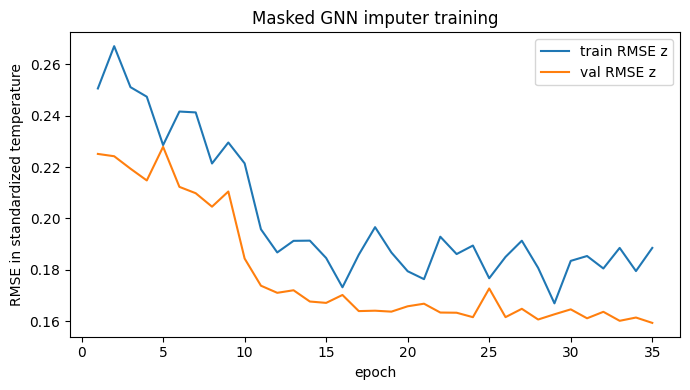

In [64]:
# ============================================================
# Optional diagnostic plots
# ============================================================

try:
    import matplotlib.pyplot as plt

    # Training curve.
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(residual_history["epoch"], residual_history["train_learned_rmse_z"], label="train RMSE z")
    ax.plot(residual_history["epoch"], residual_history["val_learned_rmse_z"], label="val RMSE z")
    ax.set_xlabel("epoch")
    ax.set_ylabel("RMSE in standardized temperature")
    ax.set_title("Masked GNN imputer training")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / "learned_imputer_training_curve.png", dpi=200)
    plt.show()

    # Baseline vs learned test RMSE.
    # The 'eval_overall' variable is not defined here, so this part will remain commented
    # or should be adjusted if 'realistic_eval_summary' is intended.
    # For now, focusing on fixing the training curve plot.
    # test_sub = eval_overall[eval_overall["split"] == "test"].copy()

    # fig, ax = plt.subplots(figsize=(5, 5))
    # ax.scatter(test_sub["baseline_rmse_C"], test_sub["learned_rmse_C"])
    # lim = [
    #     0,
    #     max(test_sub["baseline_rmse_C"].max(), test_sub["learned_rmse_C"].max()) * 1.05,
    # ]
    # ax.plot(lim, lim, linestyle="--")
    # ax.set_xlim(lim)
    # ax.set_ylim(lim)
    # ax.set_xlabel("Baseline RMSE (°C)")
    # ax.set_ylabel("Learned GNN RMSE (°C)")
    # ax.set_title("Imputation validation on artificially hidden values")
    # fig.tight_layout()
    # fig.savefig(FIG_DIR / "baseline_vs_learned_imputer_test_rmse.png", dpi=200)
    # plt.show()

except Exception as e:
    print("Plotting skipped:", e)


# SVING
